#### Install required !
###### then import it

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

#### Load Dataset

In [2]:
data = pd.read_csv(r"D:\ML,AI & DS PROJECTS\Car_Price_prediction\Data\car data.csv")
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
# Lets explore the data and see what we have
data.shape # (rows, columns)
data.info() # Data types and memory usage
data.describe() # Summary statistics for numerical columns
data.head(10) # Display first 10 rows of the dataset
# data.tail(10) # Display last 10 rows of the dataset


<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [4]:
# Check for missing values
data.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [5]:
# Check for duplicate values
data.duplicated().sum()


np.int64(2)

In [6]:
# Lets remove the duplicate values if any
data= data.drop_duplicates().reset_index(drop=True)

In [7]:
# lets check the data after removing the duplicate values
data.duplicated().sum()

np.int64(0)

#### Check some unique values

In [8]:
print("Fuel Types:")
print(data["Fuel_Type"].unique())

print("\nSelling Types:")
print(data["Selling_type"].unique())

print("\nTransmission:")
print(data["Transmission"].unique())

print("\nOwners:")
print(data["Owner"].unique())

Fuel Types:
<ArrowStringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str

Selling Types:
<ArrowStringArray>
['Dealer', 'Individual']
Length: 2, dtype: str

Transmission:
<ArrowStringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

Owners:
[0 1 3]


#####  Exploratory Data Analysis ***(EDA)**

##### Sale Price Distribution

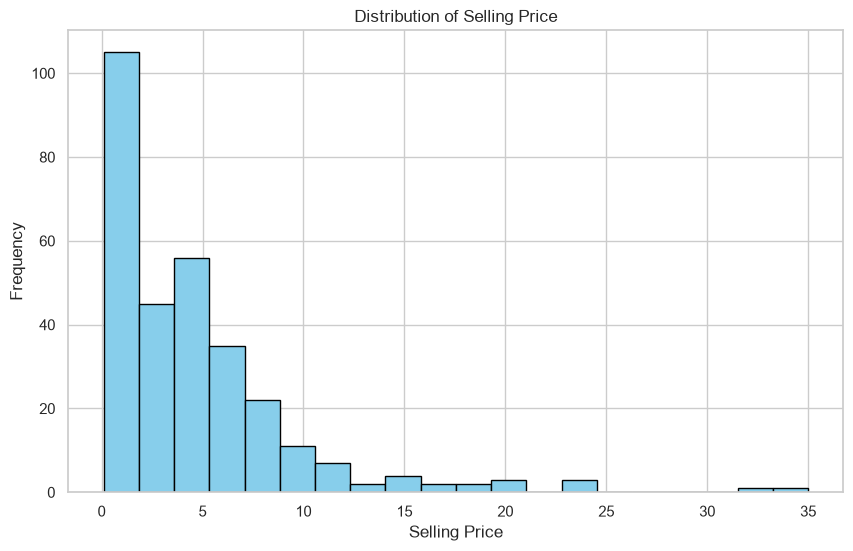

In [9]:
## Sales Price Distribution

plt.figure(figsize=(10, 6))

plt.hist(data["Selling_Price"], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()

##### Present Price vs Selling Price

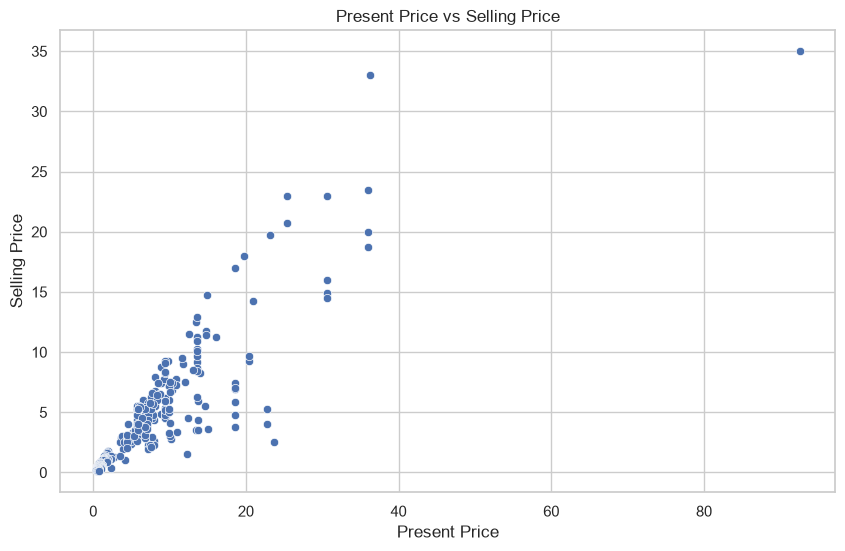

In [10]:
# Present Price vs Selling Price
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.show()

##### Year vs Selling Price

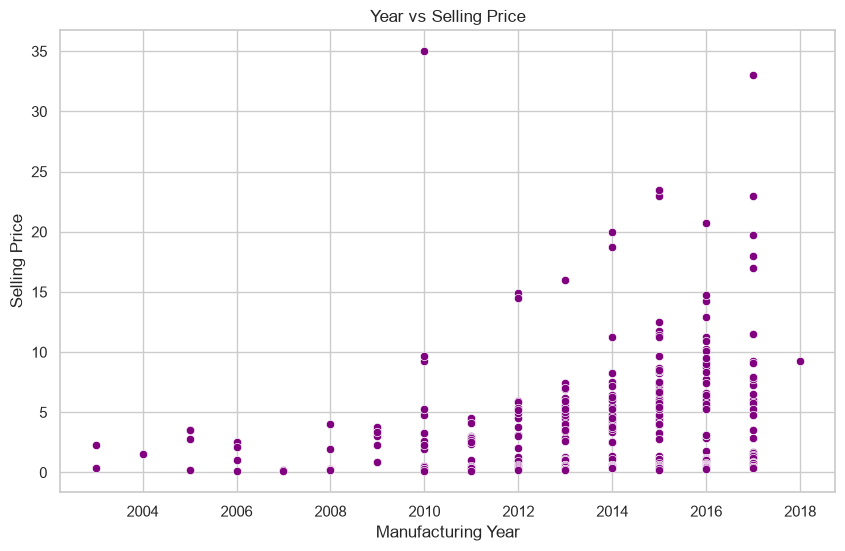

In [11]:
#Year vs Selling Price
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Year",
    y="Selling_Price",
    color='purple',
    # size=100,
    
)

plt.title("Year vs Selling Price")
plt.xlabel("Manufacturing Year")
plt.ylabel("Selling Price")
plt.show()

In [12]:
## Lets create a new feature called "Car_Age" which is the difference between the current year and the manufacturing year of the car.
Current_year = 2026
data["Car_Age"] = Current_year - data["Year"]

In [13]:
data[["Year", "Car_Age", "Selling_Price"]].head(10) # Display the first 10 rows of the selected columns

,Year,Car_Age,Selling_Price
0,2014,12,3.35
1,2013,13,4.75
2,2017,9,7.25
3,2011,15,2.85
4,2014,12,4.60
5,2018,8,9.25
6,2015,11,6.75
7,2015,11,6.50
8,2016,10,8.75
9,2015,11,7.45


##### Car Age vs Selling Price

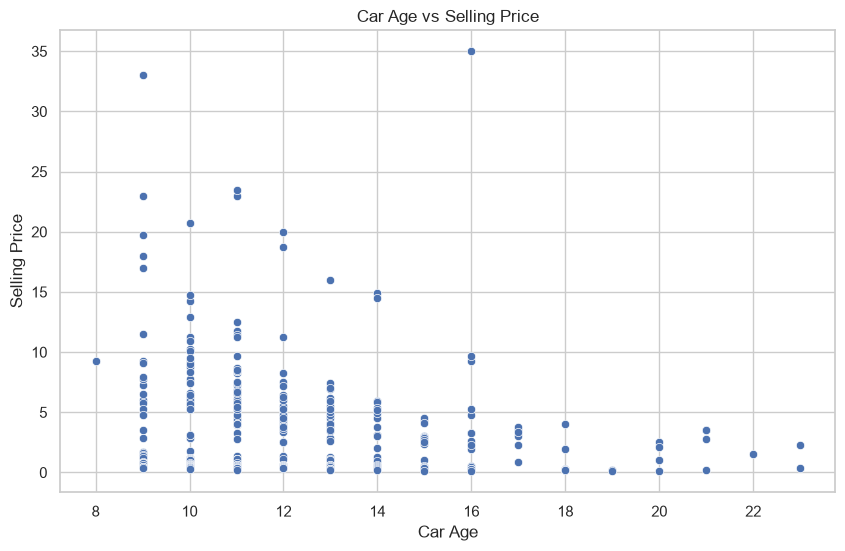

In [14]:
# Car_Age vs Selling Price

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Car_Age",
    y="Selling_Price"
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

##### Driven_Kms

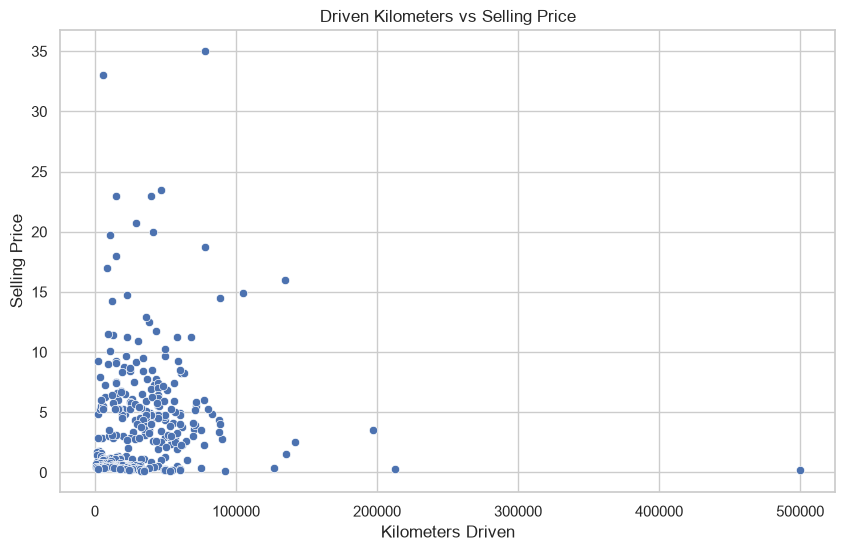

In [15]:
# Driven Kilometers vs Selling Price
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Driven_kms",
    y="Selling_Price"
)

plt.title("Driven Kilometers vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.show()

#### Car with fuel type

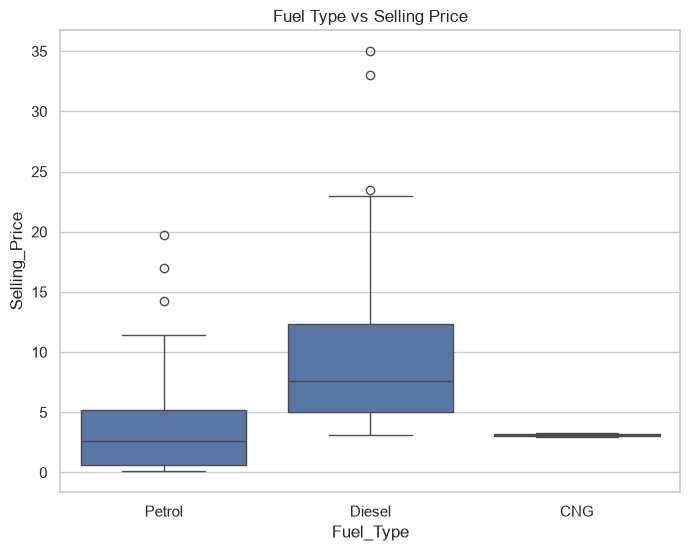

In [16]:
# Fuel Type vs Selling Price
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="Fuel_Type",
    y="Selling_Price"
)

plt.title("Fuel Type vs Selling Price")
plt.show()

##### Transmission Analysis

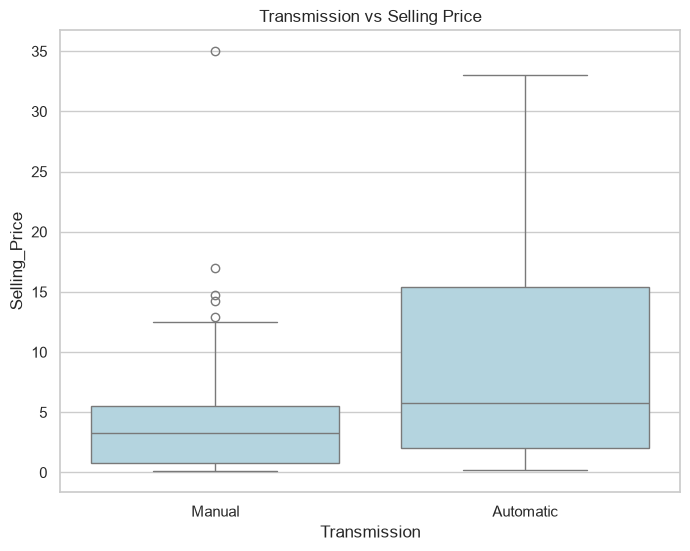

In [17]:
# Transmission vs Selling Price
# Means it whether the car is automatic or manual price of automatic cars is higher than manual cars
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="Transmission",
    y="Selling_Price",
    color='lightblue'
)

plt.title("Transmission vs Selling Price")
plt.show()

##### Selling Type X

#

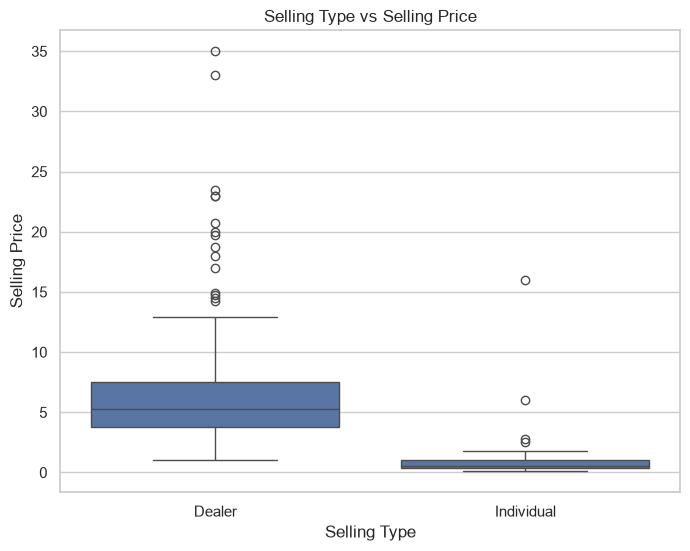

In [18]:
# Selling Type vs Selling Price
plt.figure(figsize=(8, 6))

sns.boxplot(
    data = data,
    x = "Selling_type",
    y= "Selling_Price"
)

plt.title('Selling Type vs Selling Price')
plt.xlabel('Selling Type')
plt.ylabel('Selling Price')
plt.show()


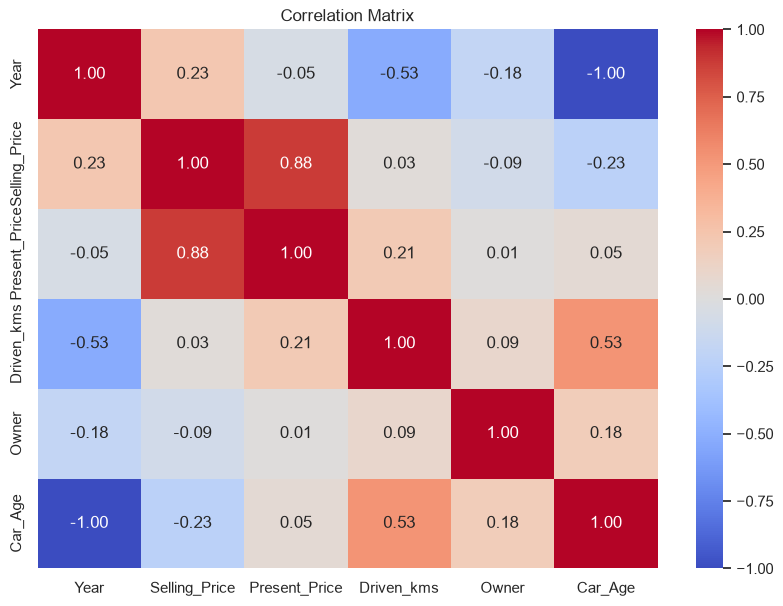

In [19]:
# coorrelation matrix  using heatmap 
plt.figure(figsize=(10, 7))

numeric_data = data.select_dtypes(include=np.number)

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

##### Outlier Treatment

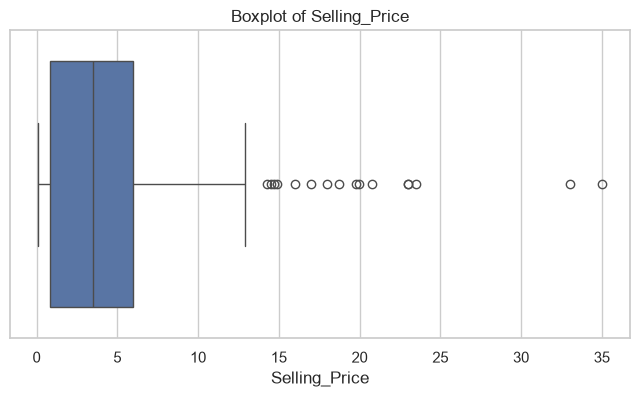

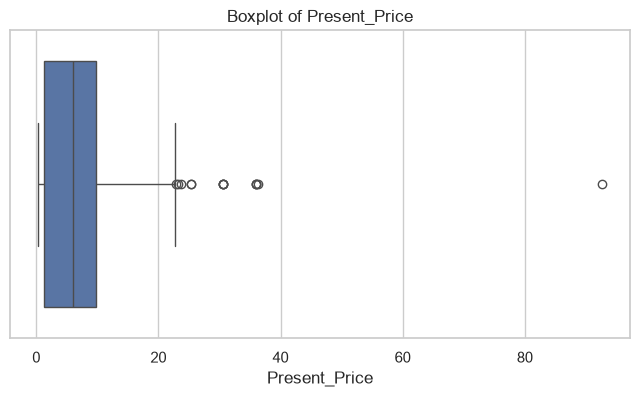

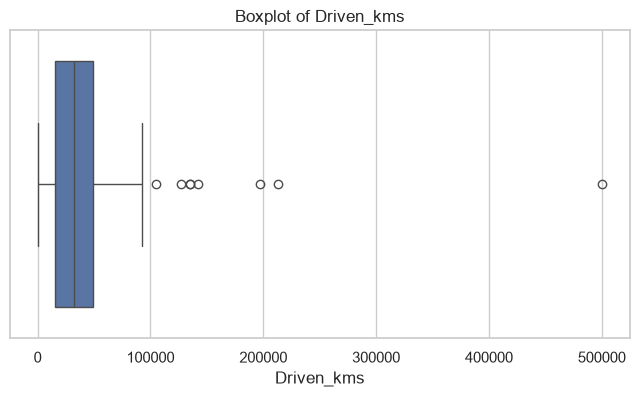

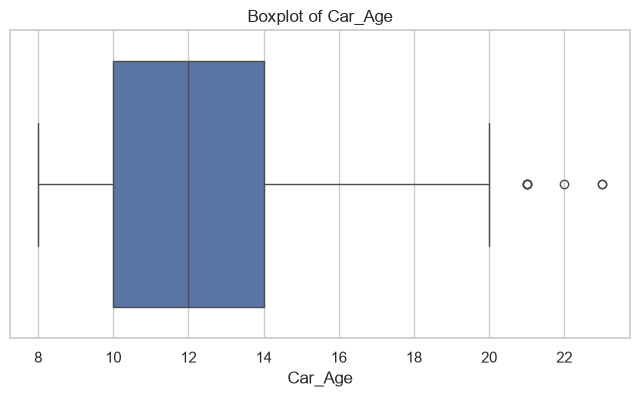

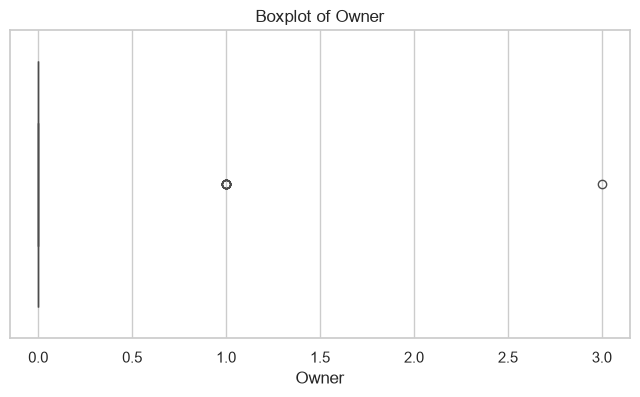

In [20]:
# Outliers Detection using boxplots for numerical features
# Create a list of numerical columns to visualize separately
numerical_columns = [
    "Selling_Price",
    "Present_Price",
    "Driven_kms",
    "Car_Age",
    "Owner"
]

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

##### Feature Engineering

In [21]:
# Feature Engineering for Categorical Variables
data["Kms_per_Year"] = (
    data["Driven_kms"] /
    data["Car_Age"].replace(0, 1)
)



In [22]:
data[
    [
        "Kms_per_Year",
    "Driven_kms",
    "Car_Age"
    ]
    
    ].head(20) # Display the first 10 rows of the selected columns

,Kms_per_Year,Driven_kms,Car_Age
0,2250.000000,27000,12
1,3307.692308,43000,13
2,766.666667,6900,9
3,346.666667,5200,15
4,3537.500000,42450,12
5,258.875000,2071,8
6,1708.727273,18796,11
7,3039.000000,33429,11
8,2027.300000,20273,10
9,3851.545455,42367,11


In [23]:
#Lets handle Car names replacing with brands and models. We will extract the brand and model from the Car_Name column and create two new columns for them.
data["Car_Name"].nunique()
# data["Brand"].nunique()

98

In [24]:
# Now, let's extract the brand and model from the "Car_Name" column. We will create two new columns: "Brand".
data["Brand"] = data["Car_Name"].str.split().str[0]  # Extract the first word as the brand

In [25]:
data[["Car_Name", "Brand"]].head(10)  # Display the first 10 rows of the selected columns

,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift
5,vitara brezza,vitara
6,ciaz,ciaz
7,s cross,s
8,ciaz,ciaz
9,ciaz,ciaz


In [26]:
#now drop the Car_Name column
data = data.drop(columns=["Car_Name"])


##### Feature & Target

In [27]:
# Now we decide features & target variable for our model. The target variable is "Selling_Price" and the features are all other columns except "Selling_Price". We will also drop the "Year" column as we have already created the "Car_Age" feature which is more relevant for our model.
y = data["Selling_Price"]
x =  data.drop(columns=["Selling_Price",])  # Features

In [28]:
x.head()

,Year,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Kms_per_Year,Brand
0,2014,5.59,27000,Petrol,Dealer,Manual,0,12,2250.000000,ritz
1,2013,9.54,43000,Diesel,Dealer,Manual,0,13,3307.692308,sx4
2,2017,9.85,6900,Petrol,Dealer,Manual,0,9,766.666667,ciaz
3,2011,4.15,5200,Petrol,Dealer,Manual,0,15,346.666667,wagon
4,2014,6.87,42450,Diesel,Dealer,Manual,0,12,3537.500000,swift


In [29]:
# y.head()

##### Let's Split the Train/Test Split

In [30]:
#Now i will split the data into training and testing sets. We will use 80% of the data for training and 20% for testing. We will also set a random state for reproducibility.
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42 # its give me roughly 80% of the data for training and 20% for testing
)

##### Dealing with Categorical & numerical

In [31]:
#categorical features
categorical_features = [
    'Fuel_Type',
    'Selling_type',
    'Transmission',
    'Brand'
]
# Numerical features
numerical_features = [
    'Year',
    'Present_Price',
    'Driven_kms',
    'Owner',
    'Car_Age',
    'Kms_per_Year'
]

##### **Preprocessing....**

In [32]:
#Preprocessing for categorical and numerical variables using ColumnTransformer
# Now combine the preprocessing steps for both categorical and numerical features using ColumnTransformer

categorical_features = [
    "Fuel_Type",
    "Selling_type",
    "Transmission",
    "Brand"
]

numerical_features = [
    "Year",
    "Present_Price",
    "Driven_kms",
    "Owner",
    "Car_Age",
    "Kms_per_Year"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


##### Let's try some baseline model

In [33]:
# Linear Regression Model
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
        
    ]
)

In [34]:
# Train the linear regression model
linear_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Year','Present_Price','Driven_kms',...,'Car_Age','Kms_per_Year','Brand']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colu

In [35]:
#predict the selling price for the test set
linear_predictions = linear_model.predict(x_test)
print("Linear Regression Model Performance:", linear_model.score(x_test, y_test) * 100)

Linear Regression Model Performance: 74.63182956669267


##### Evaluation Phase

In [36]:
#let's create a function to evaluate the model performance using metrics
# like Mean Absolute Error (MAE), Mean Squared Error (MSE)
# Root Mean Squared Error (RMSE), and R-squared (R2) score.
def evaluate_model(model, x_test, y_test):
    predictions = model.predict(x_test)
    
    mae = mean_absolute_error(
        y_test,
        predictions
    
    )
    mse = mean_squared_error(
        y_test,
        predictions
    )
    
    rmse = np.sqrt(mse)
    r2 = r2_score(
        y_test,
        predictions
    )

    return {
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
}

In [37]:
# #Evaluate the linear regression model
# linear_results = evaluate_model(
#     linear_model,
#     x_test,
#     y_test
# )

# linear_results


##### Train Multiple Models

In [38]:
# Train multiple regression models 
# Evaluate their performance using the same evaluation function.
# 1. Linear Regression
# 2.Ridge Regression
# 2. Lasso Regression
# 3. Decision Tree Regressor
# 4. Random Forest Regressor
# 5. Gradient Boosting Regressor

models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_estimators=200
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [39]:
# Train all models and evaluate their performance
results = []

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(x_train, y_train)

    metrics = evaluate_model(
        pipeline,
        x_test,
        y_test
    )

    metrics["Model"] = name

    results.append(metrics)

    trained_models[name] = pipeline

#### Compare All Models

In [40]:
#Let's compare the performance of all models in a DataFrame for better visualization.
data_results = pd.DataFrame(results)

results_df = data_results[
    [
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2"
    ]
]

results_df.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2
3,Decision Tree,0.955500,3.931945,1.982913,0.847441
0,Linear Regression,1.394547,6.538205,2.556991,0.746318
5,Gradient Boosting,1.238780,8.639801,2.939354,0.664777
1,Ridge Regression,1.774740,9.869694,3.141607,0.617057
2,Lasso Regression,1.814782,10.290222,3.207838,0.600740
4,Random Forest,1.461804,12.950322,3.598656,0.497529


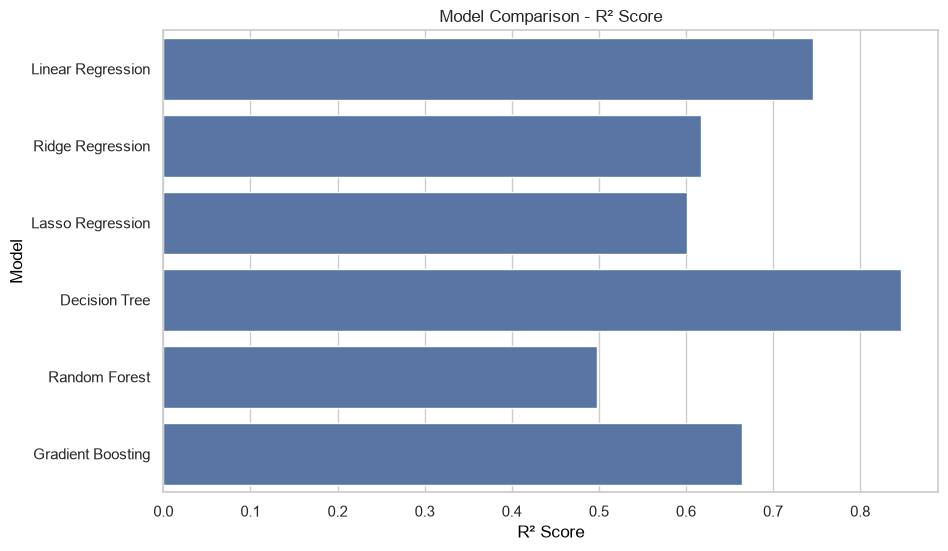

In [41]:
# Visualize the performance of all models using a bar plot for R2 score.
plt.figure(figsize=(10, 6))

sns.barplot(
    data=data_results,
    x="R2",
    y="Model"
)

plt.title("Model Comparison - R² Score")
plt.xlabel("R² Score",color='black',size=12)
plt.ylabel("Model",color='black',size=12)

plt.show()

#### Cross-validation

In [42]:
# Cross-validation for the  Random Forest model.
#Gradient Boosting,Decision Tree,with 5-fold cross-validation.
best_models = [
    "Random Forest",
    "Gradient Boosting",
    "Decision Tree"
]

In [43]:
#cross-validation results for the best models
cv_results = []

for name in best_models:

    model = trained_models[name]

    scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    cv_results.append({
        "Model": name,
        "Mean_R2": scores.mean(),
        "Std_R2": scores.std()
    })

cv_data = pd.DataFrame(cv_results)

cv_data.sort_values(
    "Mean_R2",
    ascending=False
)

,Model,Mean_R2,Std_R2
0,Random Forest,0.878033,0.120282
1,Gradient Boosting,0.855408,0.142649
2,Decision Tree,0.696287,0.366951


##### Let's try hyperparameter tuning

In [44]:
#Hyperparameter tuning for the best model (Random Forest) using GridSearchCV.
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42
            )
        )
    ]
)

In [45]:
# Parameter grid for Random Forest
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}


In [46]:
#GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
    )

In [47]:
#train the grid search on the training data
grid_search.fit(
    x_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionch

##### Best parameters

In [48]:
grid_search.best_params_

{'model__max_depth': 10,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 2,
 'model__n_estimators': 300}

In [49]:
# #Let's evaluate the best model from GridSearchCV on the test set
# rf_eval= RandomForestRegressor(n_estimators=300,
# max_depth=10,
# min_samples_leaf=2, min_samples_split=2)




In [50]:
# rf_eval.fit(
#     preprocessor.fit_transform(x_train),
#     y_train
# )

In [51]:
# Best model estimated from GridSearchCV
best_model= grid_search.best_estimator_

In [52]:
#Evaluate the best model on the test set
Final_results = evaluate_model(
    best_model,
    x_test,
    y_test
)

Final_results
    

{'MAE': 1.3835973182530075,
 'MSE': 10.997591770623995,
 'RMSE': np.float64(3.316261716243758),
 'R2': 0.5732945377344723}

##### Actual vs Predicted

In [53]:
Final_predictions = best_model.predict(x_test)

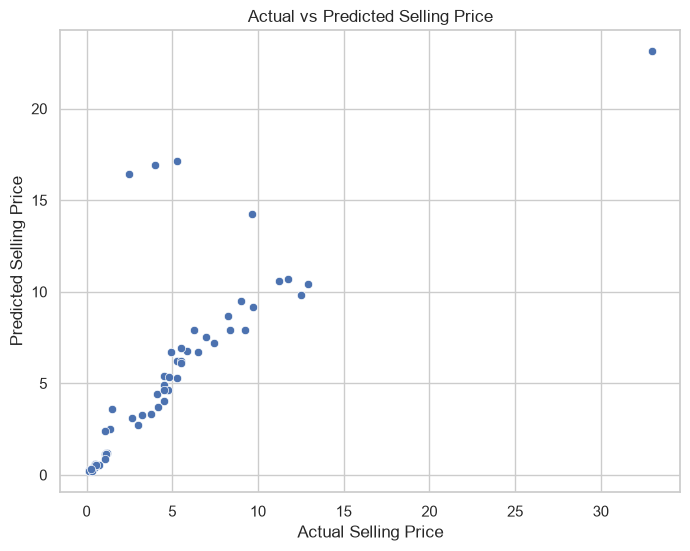

In [54]:
# Visualize the actual vs predicted selling prices for the test set using a scatter plot.
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=Final_predictions
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title(
    "Actual vs Predicted Selling Price"
)
plt.show()

##### Residual Analysis

In [55]:
# residuals = y_test - Final_predictions

In [56]:
# plt.figure(figsize=(10, 6))

# sns.scatterplot(
#     x=Final_predictions,
#     y=residuals
# )

# plt.axhline(
#     0,
#     linestyle="--"
# )

# plt.xlabel("Predicted Price")
# plt.ylabel("Residual")

# plt.title("Residual Analysis")

# plt.show()

In [57]:
# error_analysis = x_test.copy()

# error_analysis["Actual_Price"] = y_test

# error_analysis["Predicted_Price"] = Final_predictions

# error_analysis["Absolute_Error"] = np.abs(
#     y_test - Final_predictions
# )

# error_analysis.sort_values(
#     "Absolute_Error",
#     ascending=False
# ).head(10)

#### Save the Final model

In [59]:
joblib.dump(best_model,
        r"D:\ML,AI & DS PROJECTS\Car_Price_prediction\Notebook\car_price_prediction_model.pkl")

['D:\\ML,AI & DS PROJECTS\\Car_Price_prediction\\Notebook\\car_price_prediction_model.pkl']

In [61]:
#Now varify the saved model by loading it and making predictions on the test set.
import os
os.path.exists(r"D:\ML,AI & DS PROJECTS\Car_Price_prediction\Notebook\car_price_prediction_model.pkl")
# sorry for the length of path  

True

##### Test saved model 

In [63]:
# Test save model
loaded_model = joblib.load(
    r"D:\ML,AI & DS PROJECTS\Car_Price_prediction\Notebook\car_price_prediction_model.pkl"
    
)

In [64]:
#Predict it
loaded_predictions = loaded_model.predict(x_test)

In [65]:
loaded_predictions[:7]

array([ 9.51727057,  7.93793439,  0.46009889,  7.19089187, 17.11784437,
        5.27499301,  6.76188198])

In [66]:
data.head()

,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Kms_per_Year,Brand
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,2250.000000,ritz
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,3307.692308,sx4
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,766.666667,ciaz
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,346.666667,wagon
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,3537.500000,swift
